In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Store results for plotting
context_labels = []
scc_test = []
pcc_test = []

for context in ['2k', '4k', '8k']:
    if context == '2k':
        labelPath = '../../../results/PlantCAD2_tasks/exp-leaf-abs/test.tsv'
        predPath = '../../../results/PlantCAD2_tasks/exp-leaf-abs/pcv2-l24-d0768-checkpoints-lr-1e-4/predictions.csv'
    else:
        labelPath = f'../../../results/PlantCAD2_tasks/exp-leaf-abs/test_{context}.tsv'
        predPath = f'../../../results/PlantCAD2_tasks/exp-leaf-abs/pcv2-l24-d0768-{context}-checkpoints-lr-1e-4/test_{context}_predictions.tsv'
    
    labels = pd.read_csv(labelPath, sep='\t')
    predictions = pd.read_csv(predPath, sep='\t')
    
    scc = labels['Label'].corr(predictions['predicted_value'], method='spearman')
    pcc = labels['Label'].corr(predictions['predicted_value'], method='pearson')
    
   
    print(f'Context of {context}; SCC = {scc:.4f}, PCC = {pcc:.4f}')
    
    # Store for plotting
    context_labels.append(context)
    scc_test.append(scc)
    pcc_test.append(pcc)

Context of 2k; SCC = 0.6296, PCC = 0.6057
Context of 4k; SCC = 0.6428, PCC = 0.6205
Context of 8k; SCC = 0.6455, PCC = 0.6226


In [3]:
# Store results for plotting
context_labels = []
scc_valid = []
pcc_valid = []

for context in ['2k', '4k', '8k']:
    if context == '2k':
        labelPath = '../../../results/PlantCAD2_tasks/exp-leaf-abs/valid.tsv'
        predPath = '../../../results/PlantCAD2_tasks/exp-leaf-abs/pcv2-l24-d0768-checkpoints-lr-1e-4/valid_scores.tsv'
    else:
        labelPath = f'../../../results/PlantCAD2_tasks/exp-leaf-abs/valid_{context}.tsv'
        predPath = f'../../../results/PlantCAD2_tasks/exp-leaf-abs/pcv2-l24-d0768-{context}-checkpoints-lr-1e-4/valid_{context}_predictions.tsv'
    
    labels = pd.read_csv(labelPath, sep='\t')
    predictions = pd.read_csv(predPath, sep='\t')
    
    scc = labels['Label'].corr(predictions['predicted_value'], method='spearman')
    pcc = labels['Label'].corr(predictions['predicted_value'], method='pearson')
    
   
    print(f'Context of {context}; SCC = {scc:.4f}, PCC = {pcc:.4f}')
    
    # Store for plotting
    context_labels.append(context)
    scc_valid.append(scc)
    pcc_valid.append(pcc)

Context of 2k; SCC = 0.5776, PCC = 0.5678
Context of 4k; SCC = 0.5872, PCC = 0.5743
Context of 8k; SCC = 0.5888, PCC = 0.5714


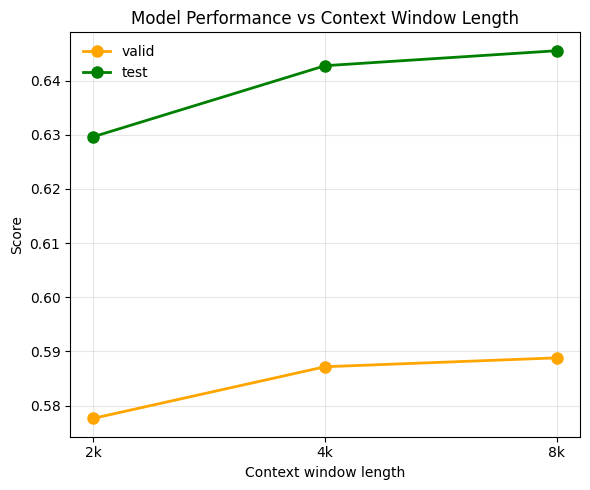

In [4]:
# Plot AUROC
plt.figure(figsize=(6, 5))
plt.plot(context_labels, scc_valid, marker='o', color='orange', linewidth=2, markersize=8, label='valid')
plt.plot(context_labels, scc_test, marker='o', color='green', linewidth=2, markersize=8, label='test')
plt.grid(True, alpha=0.3)
plt.xlabel('Context window length')
plt.ylabel('Score')
# plt.ylim(0.7,0.9)
plt.legend(frameon=False)
plt.title('Model Performance vs Context Window Length')
plt.tight_layout()
plt.savefig('performance_vs_context_window_exp-leaf-abs.pdf', format='pdf', bbox_inches='tight')
plt.show()